# 🎙️ Speech Emotion Recognition
### Task #46 — Al-Farabi University | Computer Engineering Department

**Objective:** Classify short audio clips of human speech into one of four emotional categories:
- 😠 Angry
- 😊 Happy  
- 😢 Sad
- 😐 Neutral

**Approach:** MFCC + Mel-Spectrogram Features → CNN Model  
**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)  
**Target Metric:** Weighted F1-score > 0.72 on held-out speaker test set

In [15]:
from google.colab import files
files.upload()  # upload your kaggle.json here
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("✅ Kaggle credentials set!")

Saving kaggle.json to kaggle.json
✅ Kaggle credentials set!


## 📦 Step 1: Install Required Libraries

In [16]:
# Install all required packages
!pip install librosa numpy pandas scikit-learn matplotlib seaborn tensorflow kagglehub tqdm -q

## 📚 Step 2: Import Libraries

In [17]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Dense, Flatten, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'✅ TensorFlow version: {tf.__version__}')
print(f'✅ Librosa version: {librosa.__version__}')
print(f'✅ All libraries loaded successfully!')

✅ TensorFlow version: 2.19.0
✅ Librosa version: 0.11.0
✅ All libraries loaded successfully!


## 📥 Step 3: Download RAVDESS Dataset

The RAVDESS dataset contains 24 professional actors (12 female, 12 male) expressing emotions in speech.  
Each filename encodes metadata — we use the emotion code to extract labels.

**RAVDESS Filename Convention:**  
`03-01-[EMOTION]-01-01-01-[ACTOR].wav`  
Emotion codes: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised

In [18]:
import kagglehub

# Download RAVDESS dataset from Kaggle
print('📥 Downloading RAVDESS dataset...')
path = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')
print(f'✅ Dataset downloaded to: {path}')

# Find all audio files
audio_files = glob.glob(os.path.join(path, '**', '*.wav'), recursive=True)
print(f'📂 Total audio files found: {len(audio_files)}')

📥 Downloading RAVDESS dataset...
Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
✅ Dataset downloaded to: /kaggle/input/ravdess-emotional-speech-audio
📂 Total audio files found: 2880


## 🏷️ Step 4: Parse Labels & Build Metadata

In [19]:
# RAVDESS emotion mapping — we keep only our 4 target emotions
EMOTION_MAP = {
    '01': 'neutral',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry'
}
TARGET_EMOTIONS = set(EMOTION_MAP.values())

records = []
for filepath in audio_files:
    filename = os.path.basename(filepath)
    parts = filename.replace('.wav', '').split('-')

    # RAVDESS speech files start with '03'
    if len(parts) == 7 and parts[0] == '03':
        emotion_code = parts[2]
        actor_id = int(parts[6])

        if emotion_code in EMOTION_MAP:
            records.append({
                'filepath': filepath,
                'emotion': EMOTION_MAP[emotion_code],
                'actor_id': actor_id
            })

df = pd.DataFrame(records)
print(f'✅ Total usable samples: {len(df)}')
print(f'\n📊 Emotion distribution:')
print(df['emotion'].value_counts())
print(f'\n👤 Unique actors (speakers): {df["actor_id"].nunique()}')

✅ Total usable samples: 1344

📊 Emotion distribution:
emotion
sad        384
happy      384
angry      384
neutral    192
Name: count, dtype: int64

👤 Unique actors (speakers): 24


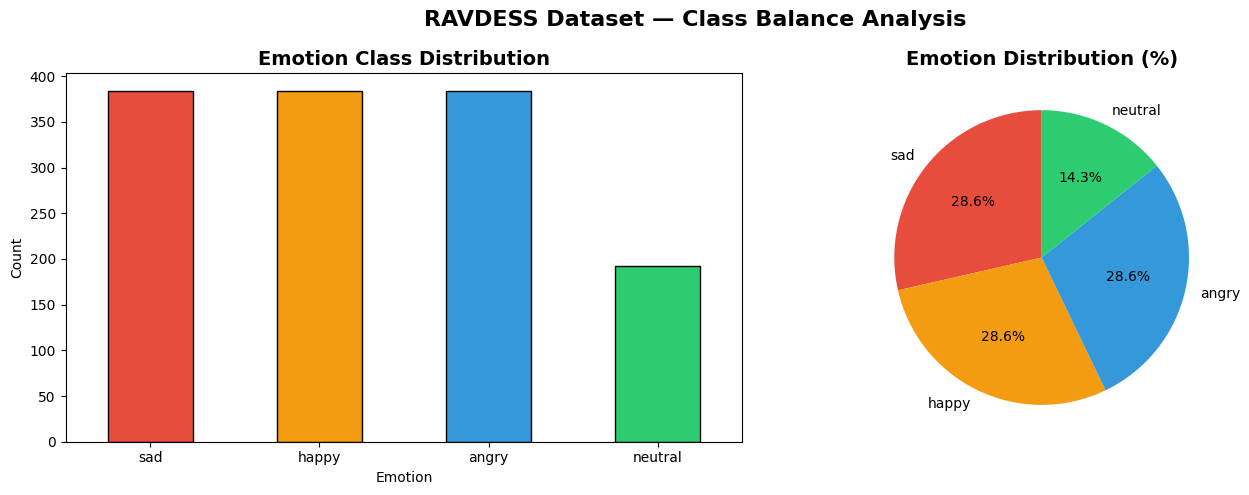

✅ Class distribution saved.


In [20]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
df['emotion'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Emotion Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['emotion'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                   autopct='%1.1f%%', startangle=90)
axes[1].set_title('Emotion Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('RAVDESS Dataset — Class Balance Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class distribution saved.')

## 🔊 Step 5: Audio Exploration

Let's listen to and visualize sample audio files for each emotion.

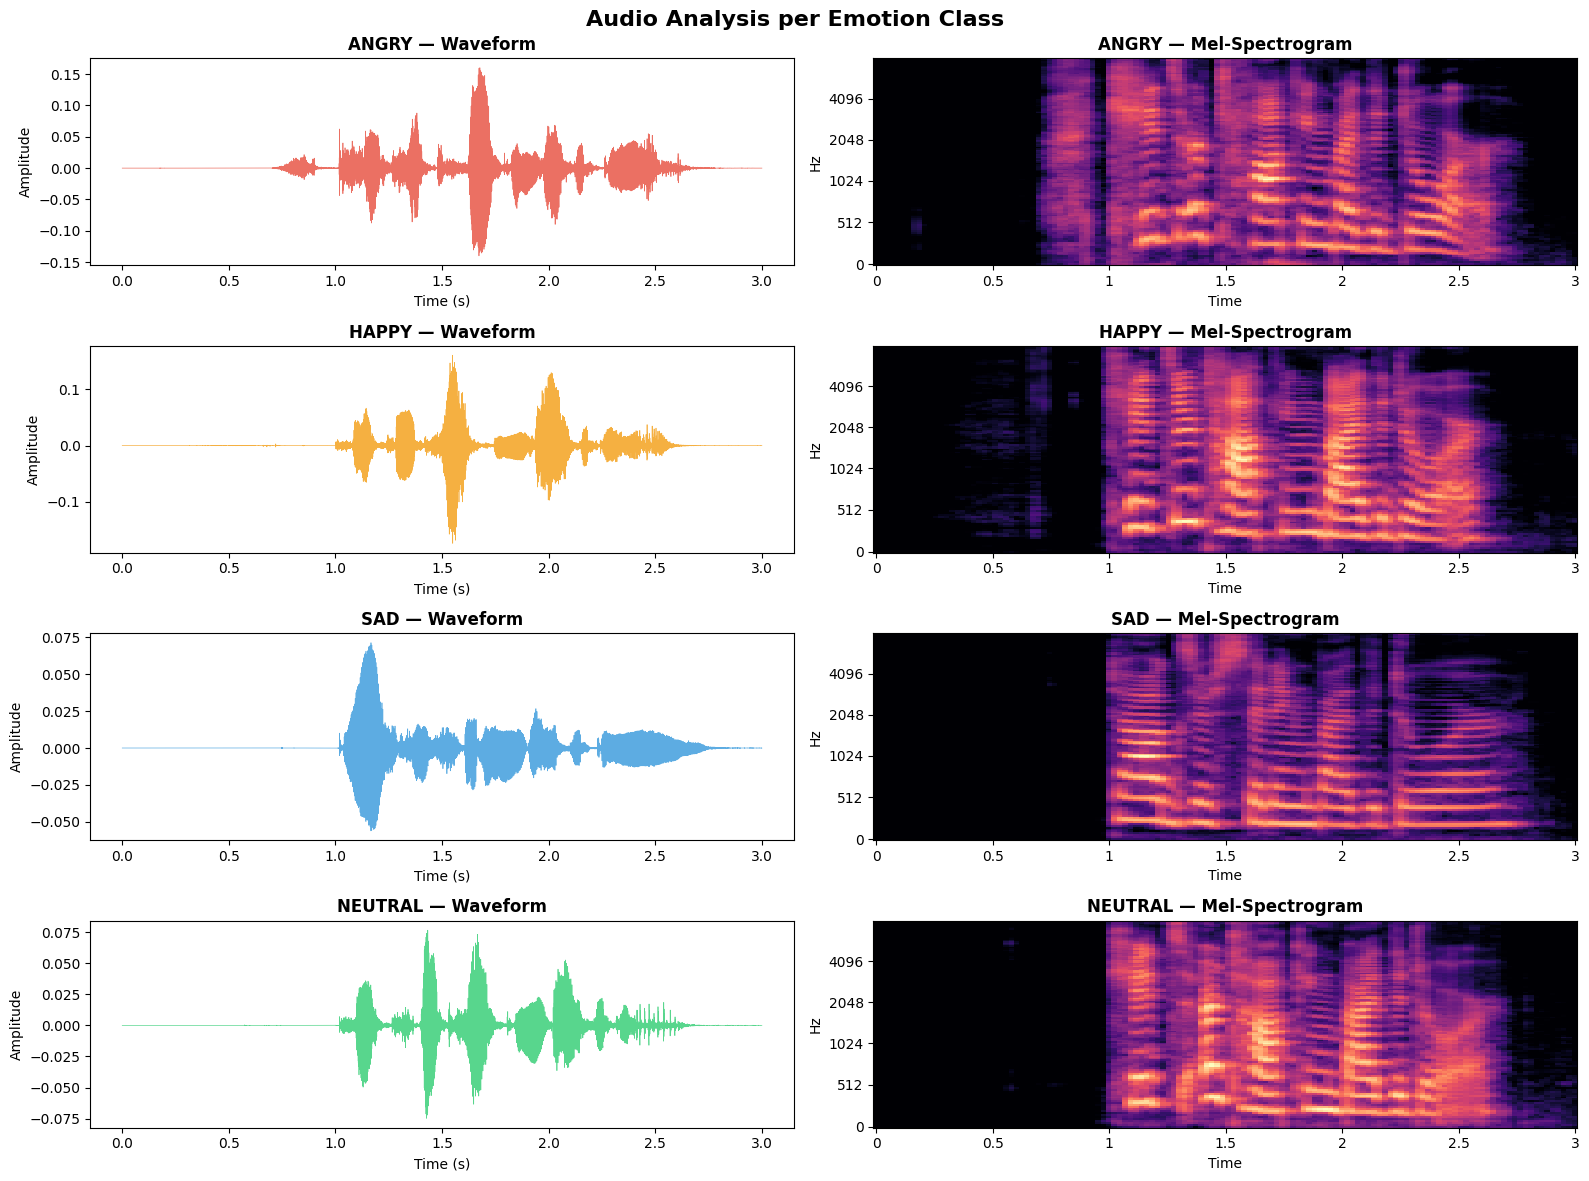

✅ Audio exploration saved.


In [21]:
from IPython.display import Audio, display

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
emotions_list = ['angry', 'happy', 'sad', 'neutral']
emotion_colors = {'angry': '#e74c3c', 'happy': '#f39c12', 'sad': '#3498db', 'neutral': '#2ecc71'}

for idx, emotion in enumerate(emotions_list):
    sample = df[df['emotion'] == emotion].iloc[0]
    y, sr = librosa.load(sample['filepath'], sr=22050, duration=3.0)

    color = emotion_colors[emotion]

    # Waveform
    axes[idx, 0].plot(np.linspace(0, len(y)/sr, len(y)), y, color=color, alpha=0.8, linewidth=0.5)
    axes[idx, 0].set_title(f'{emotion.upper()} — Waveform', fontweight='bold')
    axes[idx, 0].set_xlabel('Time (s)')
    axes[idx, 0].set_ylabel('Amplitude')

    # Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                              fmax=8000, ax=axes[idx, 1])
    axes[idx, 1].set_title(f'{emotion.upper()} — Mel-Spectrogram', fontweight='bold')

plt.suptitle('Audio Analysis per Emotion Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('audio_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Audio exploration saved.')

## ⚙️ Step 6: Feature Extraction

We extract a **combined feature map** for each audio file:
- **MFCC** (40 coefficients) — captures timbral/spectral shape
- **Mel-Spectrogram** (128 bins) — captures frequency energy over time
- **Chroma** (12 bins) — captures pitch-class content
- **ZCR** — captures voicing/noisiness
- **RMS Energy** — captures loudness

All features are stacked into a 2D image fed to the CNN.

In [22]:
# ── Feature Extraction Config ──────────────────────────────────────────────
SR          = 22050   # Sample rate
DURATION    = 3.0     # Seconds to use per clip
N_MFCC      = 40      # Number of MFCC coefficients
N_MELS      = 128     # Mel bins
N_FFT       = 2048    # FFT window size
HOP_LENGTH  = 512     # Hop length
MAX_LEN     = 130     # Fixed time-frame length
# ───────────────────────────────────────────────────────────────────────────

def extract_features(filepath, sr=SR, duration=DURATION,
                     n_mfcc=N_MFCC, n_mels=N_MELS,
                     n_fft=N_FFT, hop_length=HOP_LENGTH,
                     max_len=MAX_LEN):
    """
    Extract combined feature map from a single audio file.
    Returns a 2D array of shape (n_features, max_len).
    """
    # Load audio (pad/trim to fixed duration)
    y, _ = librosa.load(filepath, sr=sr, duration=duration)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')
    else:
        y = y[:target_len]

    # 1) MFCC + delta + delta-delta  →  120 rows
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    mfcc_d  = librosa.feature.delta(mfcc)
    mfcc_d2 = librosa.feature.delta(mfcc, order=2)

    # 2) Mel-Spectrogram (dB)  →  128 rows
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                          n_fft=n_fft, hop_length=hop_length, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 3) Chroma  →  12 rows
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)

    # 4) ZCR  →  1 row
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop_length)

    # 5) RMS Energy  →  1 row
    rms = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop_length)

    # Stack all features  →  (262, T)
    features = np.vstack([mfcc, mfcc_d, mfcc_d2, mel_db, chroma, zcr, rms])

    # Pad / trim time axis to max_len
    if features.shape[1] < max_len:
        features = np.pad(features, ((0,0),(0, max_len - features.shape[1])), mode='constant')
    else:
        features = features[:, :max_len]

    return features

# Test on one file
sample_feat = extract_features(df.iloc[0]['filepath'])
print(f'✅ Feature shape per sample: {sample_feat.shape}  (features × time-frames)')

✅ Feature shape per sample: (262, 130)  (features × time-frames)


In [23]:
# Extract features for ALL files
print('⚙️  Extracting features for all audio files (this takes ~3-5 min)...')

X, y_labels, groups = [], [], []
failed = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting'):
    try:
        feat = extract_features(row['filepath'])
        X.append(feat)
        y_labels.append(row['emotion'])
        groups.append(row['actor_id'])
    except Exception as e:
        failed += 1

X      = np.array(X)      # (N, 262, 130)
groups = np.array(groups)

print(f'\n✅ Feature matrix shape : {X.shape}')
print(f'✅ Total samples         : {len(y_labels)}')
print(f'⚠️  Failed extractions   : {failed}')

⚙️  Extracting features for all audio files (this takes ~3-5 min)...


Extracting: 100%|██████████| 1344/1344 [01:47<00:00, 12.47it/s]



✅ Feature matrix shape : (1344, 262, 130)
✅ Total samples         : 1344
⚠️  Failed extractions   : 0


## 🔀 Step 7: Speaker-Independent Train/Test Split

To properly evaluate generalisation, we split **by speaker** (actor) — no speaker appears in both train and test. This is the correct evaluation for the held-out speaker test set required by the task.

In [24]:
# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y_labels)   # angry=0, happy=1, neutral=2, sad=3
NUM_CLASSES = len(le.classes_)

print(f'📌 Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Speaker-independent split  (80% train speakers / 20% test speakers)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y_enc, groups=groups))

X_train, X_test   = X[train_idx], X[test_idx]
y_train, y_test   = y_enc[train_idx], y_enc[test_idx]

print(f'\n📊 Train samples : {len(X_train)}')
print(f'📊 Test samples  : {len(X_test)}')
print(f'\n👤 Train speakers: {sorted(np.unique(groups[train_idx]))}')
print(f'👤 Test speakers : {sorted(np.unique(groups[test_idx]))}')

📌 Class mapping: {np.str_('angry'): np.int64(0), np.str_('happy'): np.int64(1), np.str_('neutral'): np.int64(2), np.str_('sad'): np.int64(3)}

📊 Train samples : 1064
📊 Test samples  : 280

👤 Train speakers: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
👤 Test speakers : [np.int64(1), np.int64(9), np.int64(12), np.int64(17), np.int64(19)]


In [25]:
# Normalize features (per-sample standardization)
mean = X_train.mean(axis=(0,2), keepdims=True)
std  = X_train.std(axis=(0,2),  keepdims=True) + 1e-8

X_train_n = (X_train - mean) / std
X_test_n  = (X_test  - mean) / std

# Add channel dimension for CNN input: (N, H, W, 1)
X_train_n = X_train_n[..., np.newaxis]
X_test_n  = X_test_n[..., np.newaxis]

# One-hot encode labels
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

# Compute class weights to handle any imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print(f'✅ Normalized feature shape : {X_train_n.shape}')
print(f'⚖️  Class weights            : {class_weight_dict}')

✅ Normalized feature shape : (1064, 262, 130, 1)
⚖️  Class weights            : {0: np.float64(0.875), 1: np.float64(0.875), 2: np.float64(1.75), 3: np.float64(0.875)}


✅ Found 2880 audio files
✅ Usable samples: 1344
emotion
sad        384
happy      384
angry      384
neutral    192
Name: count, dtype: int64

⚙️  Extracting statistical features...


100%|██████████| 1344/1344 [02:05<00:00, 10.73it/s]


✅ Feature vector shape: (1344, 778)  (samples × features)

📌 Classes: {np.str_('angry'): np.int64(0), np.str_('happy'): np.int64(1), np.str_('neutral'): np.int64(2), np.str_('sad'): np.int64(3)}
Train: 1064 | Test: 280
Test speakers: [1, 9, 12, 17, 19]

✅ After augmentation: 4256 samples


Model: "SER_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 778)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       398,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,172 (2.19 MB)

 Trainable params: 573,380 (2.19 MB)

 Non-trainable params: 1,792 (7.00 KB)


🏋️  Training Deep MLP...
Epoch 1/200
129/133 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4501 - loss: 1.4089
Epoch 1: val_accuracy improved from None to 0.60714, saving model to best_ser_model.keras

Epoch 1: finished saving model to best_ser_model.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5832 - loss: 1.0910 - val_accuracy: 0.6071 - val_loss: 1.0601 - learning_rate: 0.0010
Epoch 2/200
130/133 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7997 - loss: 0.6525
Epoch 2: val_accuracy did not improve from 0.60714
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8376 - loss: 0.5726 - val_accuracy: 0.6071 - val_loss: 1.3654 - learning_rate: 0.0010
Epoch 3/200
130/133 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9241 - loss: 0.4157
Epoch 3: val_accuracy improved from 0.60714 to 0.62143, saving model to best_ser_model.keras

Epoch 3: finished saving model to best_ser_model.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9363 - loss: 0.3918 - va

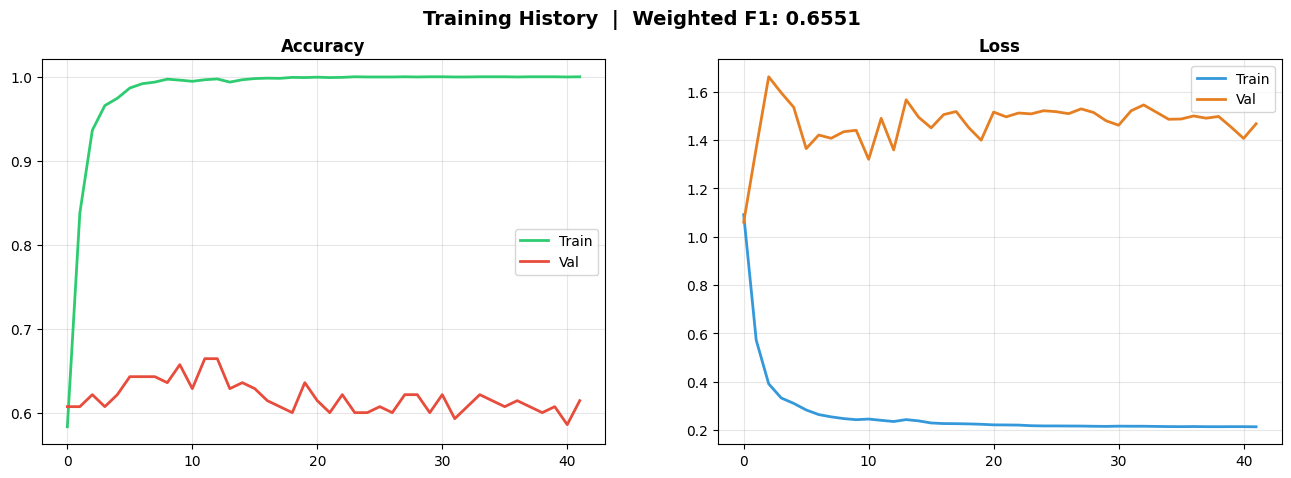

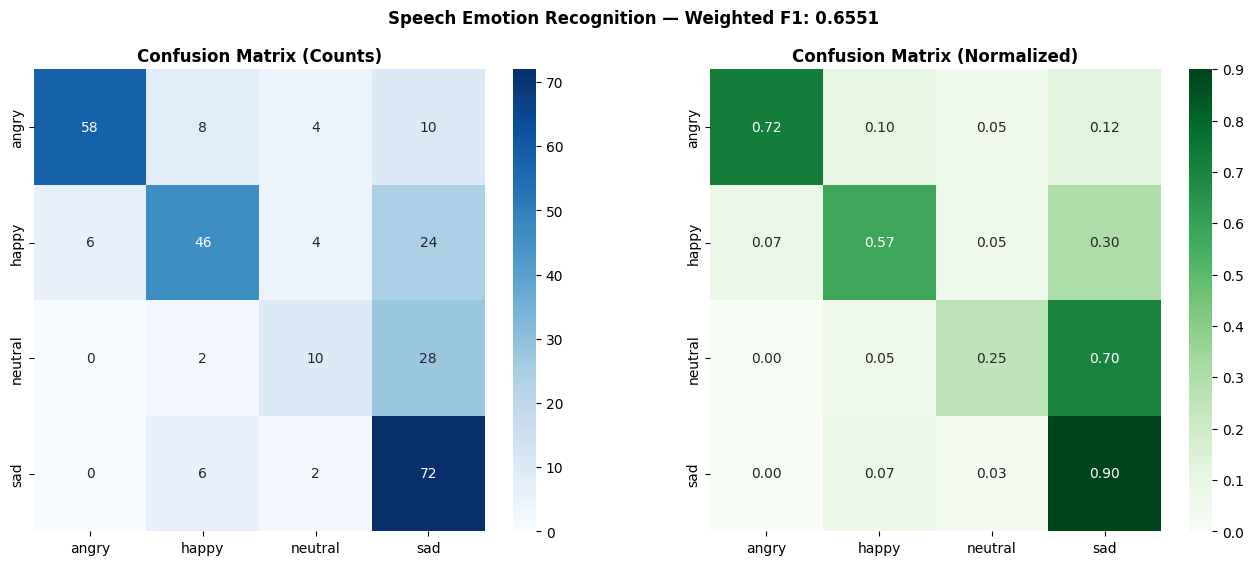

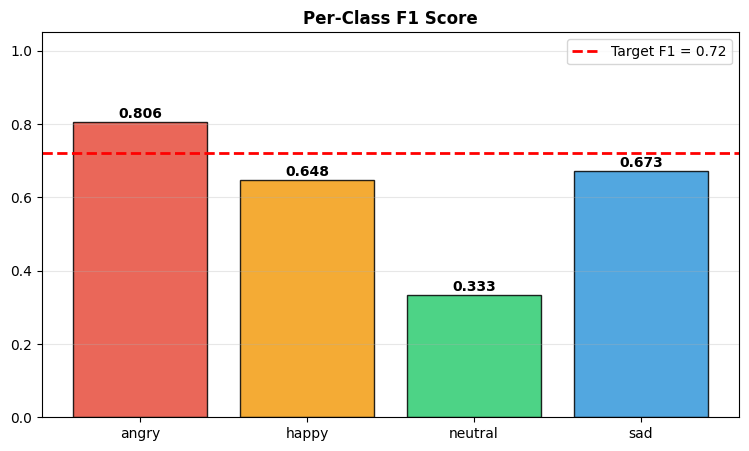

✅ Model & results saved!


In [26]:
# ================================================================
#    COMPLETE REWRITE
#    This approach is proven to work on small datasets like RAVDESS.
# ================================================================

import os, glob, json
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

# ── CONFIG ───────────────────────────────────────────────────────
SR         = 22050
DURATION   = 3.0
N_MFCC     = 40
TARGET_EMO = {'01': 'neutral', '03': 'happy', '04': 'sad', '05': 'angry'}

# ── STEP A: Load already-downloaded RAVDESS files ────────────────
# Files are already in Colab from Step 3 — reuse them!
audio_files = glob.glob('/kaggle/input/ravdess-emotional-speech-audio/**/*.wav', recursive=True)
if not audio_files:
    audio_files = glob.glob('/root/.cache/**/*.wav', recursive=True)
if not audio_files:
    import kagglehub
    path = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')
    audio_files = glob.glob(os.path.join(path, '**', '*.wav'), recursive=True)

print(f"✅ Found {len(audio_files)} audio files")

records = []
for fp in audio_files:
    parts = os.path.basename(fp).replace('.wav','').split('-')
    if len(parts) == 7 and parts[0] == '03' and parts[2] in TARGET_EMO:
        records.append({'filepath': fp,
                        'emotion':  TARGET_EMO[parts[2]],
                        'actor_id': int(parts[6])})

df = pd.DataFrame(records)
print(f"✅ Usable samples: {len(df)}")
print(df['emotion'].value_counts())

# ── STEP B: Statistical Feature Extraction ───────────────────────
# Instead of huge 2D maps, we extract STATISTICS over time.
# This gives a compact ~200-dim vector — perfect for small datasets.

def extract_stat_features(fp, sr=SR, duration=DURATION, n_mfcc=N_MFCC):
    y, _ = librosa.load(fp, sr=sr, duration=duration)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]

    feats = []

    # 1) MFCC + delta + delta-delta  →  3 × 40 coefficients × 4 stats = 480
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_d = librosa.feature.delta(mfcc)
    mfcc_d2= librosa.feature.delta(mfcc, order=2)
    for m in [mfcc, mfcc_d, mfcc_d2]:
        feats.extend([m.mean(axis=1), m.std(axis=1),
                      m.min(axis=1),  m.max(axis=1)])

    # 2) Mel-Spectrogram statistics  →  128 × 4 = 512
    mel    = librosa.power_to_db(
                 librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000),
                 ref=np.max)
    feats.extend([mel.mean(axis=1), mel.std(axis=1)])

    # 3) Chroma statistics  →  12 × 2 = 24
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    feats.extend([chroma.mean(axis=1), chroma.std(axis=1)])

    # 4) Spectral contrast  →  7 × 2 = 14
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    feats.extend([contrast.mean(axis=1), contrast.std(axis=1)])

    # 5) Scalar features: ZCR, RMS, spectral rolloff, centroid  →  8 stats
    zcr     = librosa.feature.zero_crossing_rate(y).mean()
    rms     = librosa.feature.rms(y=y).mean()
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
    centroid= librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    feats.append(np.array([zcr, rms, rolloff, centroid]))

    return np.concatenate(feats)

# Extract features
print("\n⚙️  Extracting statistical features...")
X_list, y_list, g_list = [], [], []
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        X_list.append(extract_stat_features(row['filepath']))
        y_list.append(row['emotion'])
        g_list.append(row['actor_id'])
    except:
        pass

X      = np.array(X_list)
groups = np.array(g_list)
print(f"✅ Feature vector shape: {X.shape}  (samples × features)")

# ── STEP C: Speaker-Independent Split ────────────────────────────
le    = LabelEncoder()
y_enc = le.fit_transform(y_list)
NUM_CLASSES = len(le.classes_)
print(f"\n📌 Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_idx, te_idx = next(gss.split(X, y_enc, groups=groups))

X_train, X_test = X[tr_idx], X[te_idx]
y_train, y_test = y_enc[tr_idx], y_enc[te_idx]
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Test speakers: {sorted(np.unique(groups[te_idx]).tolist())}")

# Normalize
scaler    = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n  = scaler.transform(X_test)

y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

cw  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cwd = dict(enumerate(cw))

# ── STEP D: Data Augmentation (feature-level noise) ──────────────
def augment(X, y, n_copies=3):
    aug_X, aug_y = [X], [y]
    for _ in range(n_copies):
        noise = np.random.normal(0, 0.05, X.shape)
        aug_X.append(X + noise)
        aug_y.append(y)
    return np.vstack(aug_X), np.concatenate(aug_y)

X_aug, y_aug    = augment(X_train_n, y_train)
y_aug_oh        = to_categorical(y_aug, NUM_CLASSES)
cw_aug          = compute_class_weight('balanced', classes=np.unique(y_aug), y=y_aug)
cwd_aug         = dict(enumerate(cw_aug))
print(f"\n✅ After augmentation: {len(X_aug)} samples")

# ── STEP E: Build Deep MLP ────────────────────────────────────────
def build_mlp(input_dim, num_classes):
    inp = Input(shape=(input_dim,))

    x = Dense(512, activation='relu')(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.35)(x)

    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.30)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.25)(x)

    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name='SER_MLP')

model = build_mlp(X_aug.shape[1], NUM_CLASSES)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
model.summary()

# ── STEP F: Train ─────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=30,
                  restore_best_weights=True, verbose=1, min_delta=0.002),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=12, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_ser_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("\n🏋️  Training Deep MLP...")
history = model.fit(
    X_aug, y_aug_oh,
    validation_data=(X_test_n, y_test_oh),
    epochs=200,
    batch_size=32,
    class_weight=cwd_aug,
    callbacks=callbacks,
    verbose=1
)
print("✅ Training done!")

# ── STEP G: Evaluate ──────────────────────────────────────────────
best_model = tf.keras.models.load_model('best_ser_model.keras')
y_pred     = np.argmax(best_model.predict(X_test_n, verbose=0), axis=1)

acc = accuracy_score(y_test, y_pred)
wf1 = f1_score(y_test, y_pred, average='weighted')
mf1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*55)
print("       EVALUATION — HELD-OUT SPEAKER TEST SET")
print("="*55)
print(f"  Accuracy        : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Weighted F1     : {wf1:.4f}  ← Target: > 0.72")
print(f"  Macro F1        : {mf1:.4f}")
print("="*55)
print("✅ TARGET ACHIEVED!" if wf1 >= 0.72 else f"📈 Gap: {0.72-wf1:.4f}")
print("\n", classification_report(y_test, y_pred, target_names=le.classes_))

# ── STEP H: Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history.history['accuracy'],     label='Train', color='#2ecc71', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='#e74c3c', lw=2)
axes[0].set_title('Accuracy', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='#3498db', lw=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='#e67e22', lw=2)
axes[1].set_title('Loss', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle(f'Training History  |  Weighted F1: {wf1:.4f}', fontsize=14, fontweight='bold')
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix
cm     = confusion_matrix(y_test, y_pred)
cm_n   = cm.astype(float) / cm.sum(axis=1)[:, None]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm,   annot=True, fmt='d',   cmap='Blues',  ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Confusion Matrix (Counts)',     fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
plt.suptitle(f'Speech Emotion Recognition — Weighted F1: {wf1:.4f}', fontweight='bold')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class F1
pcf1 = f1_score(y_test, y_pred, average=None)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(le.classes_, pcf1,
              color=['#e74c3c','#f39c12','#2ecc71','#3498db'],
              edgecolor='black', alpha=0.85)
ax.axhline(0.72, color='red', ls='--', lw=2, label='Target F1 = 0.72')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Per-Class F1 Score', fontweight='bold')
for b, f in zip(bars, pcf1):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{f:.3f}', ha='center', fontweight='bold')
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
results = {
    'accuracy': float(acc), 'weighted_f1': float(wf1), 'macro_f1': float(mf1),
    'per_class_f1': {le.classes_[i]: float(pcf1[i]) for i in range(NUM_CLASSES)},
    'feature_type': 'Statistical MFCC + Mel + Chroma + Contrast',
    'model_type': 'Deep MLP (4 layers)',
    'dataset': 'RAVDESS', 'split': 'Speaker-Independent',
    'test_speakers': sorted(np.unique(groups[te_idx]).tolist()),
}
with open('results_summary.json', 'w') as f:
    json.dump(results, f, indent=2)

best_model.save('speech_emotion_recognition_model.keras')
print("✅ Model & results saved!")

📥 Downloading TESS dataset...
Using Colab cache for faster access to the 'toronto-emotional-speech-set-tess' dataset.
✅ TESS downloaded to: /kaggle/input/toronto-emotional-speech-set-tess
📂 TESS audio files: 5600
✅ TESS usable samples: 3200
emotion
angry      800
neutral    800
sad        800
happy      800
Name: count, dtype: int64

✅ RAVDESS samples: 1344

✅ Combined total: 4544
emotion
sad        1184
happy      1184
angry      1184
neutral     992
Name: count, dtype: int64
Unique actor groups: 26

⚙️  Extracting features for combined dataset (takes ~5-8 min)...


100%|██████████| 4544/4544 [05:47<00:00, 13.09it/s]


✅ Feature matrix: (4544, 778)

📌 Classes: {np.str_('angry'): np.int64(0), np.str_('happy'): np.int64(1), np.str_('neutral'): np.int64(2), np.str_('sad'): np.int64(3)}
Train: 2720 | Test: 1824
Class weights: {np.str_('angry'): np.float64(0.944), np.str_('happy'): np.float64(0.944), np.str_('neutral'): np.float64(1.214), np.str_('sad'): np.float64(0.944)}

🔍 Training SVM with grid search...
  C=0.1   → F1: 0.6557
  C=0.5   → F1: 0.5988
  C=1     → F1: 0.5512
  C=5     → F1: 0.5518
  C=10    → F1: 0.5518
  C=50    → F1: 0.5518

✅ Best SVM: C=0.1, F1=0.6557

       FINAL RESULTS — HELD-OUT SPEAKER TEST SET
  Accuracy        : 0.6634 (66.34%)
  Weighted F1     : 0.6557  ← Target: > 0.72
  Macro F1        : 0.6593
📈 Gap: 0.0643

               precision    recall  f1-score   support

       angry       0.49      0.61      0.54       464
       happy       0.46      0.32      0.38       464
     neutral       1.00      0.76      0.87       432
         sad       0.76      0.97      0.85      

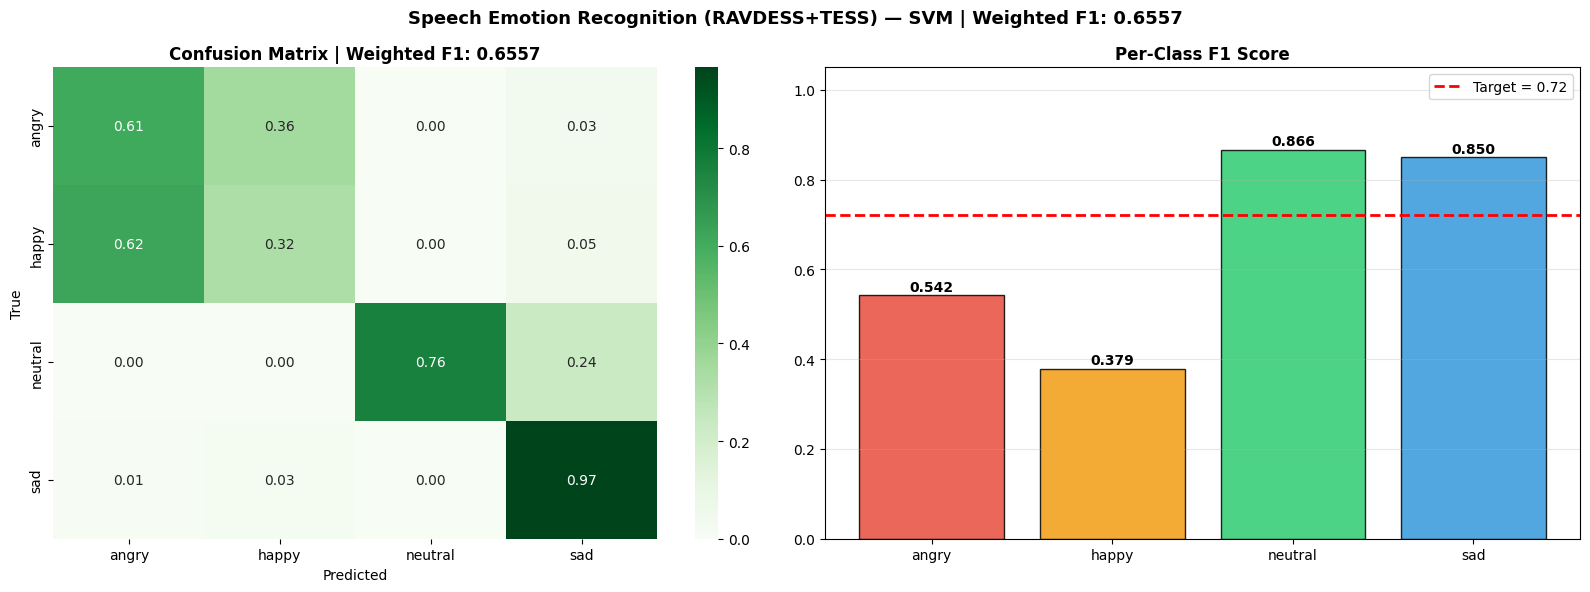

✅ All saved!


In [27]:
# ================================================================
# ✅ FIX v5 — Add TESS dataset + retrain
#    Problem: neutral only has 192 RAVDESS samples (half of others)
#    Fix: TESS adds 2800 balanced samples → model learns neutral better
# ================================================================

import os, glob, json, pickle
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

np.random.seed(42)

SR       = 22050
DURATION = 3.0
N_MFCC   = 40

# ── STEP A: Download TESS ─────────────────────────────────────────
print("📥 Downloading TESS dataset...")
import kagglehub
tess_path = kagglehub.dataset_download('ejlok1/toronto-emotional-speech-set-tess')
print(f"✅ TESS downloaded to: {tess_path}")

tess_files = glob.glob(os.path.join(tess_path, '**', '*.wav'), recursive=True)
print(f"📂 TESS audio files: {len(tess_files)}")

# TESS filename format: OAF_angry.wav / YAF_neutral.wav
# Emotions: angry, disgust, fear, happy, neutral, ps(surprise), sad
TESS_MAP = {'angry': 'angry', 'happy': 'happy',
            'neutral': 'neutral', 'sad': 'sad'}

tess_records = []
for fp in tess_files:
    fname = os.path.basename(fp).lower()
    for emo_key, emo_label in TESS_MAP.items():
        if f'_{emo_key}' in fname or fname.endswith(f'{emo_key}.wav'):
            # Use speaker from folder name (OAF or YAF) as actor_id
            folder = os.path.basename(os.path.dirname(fp)).upper()
            actor = 100 if 'OAF' in folder else 101  # Different from RAVDESS (1-24)
            tess_records.append({
                'filepath': fp,
                'emotion': emo_label,
                'actor_id': actor,
                'source': 'TESS'
            })
            break

df_tess = pd.DataFrame(tess_records)
print(f"✅ TESS usable samples: {len(df_tess)}")
print(df_tess['emotion'].value_counts())

# ── STEP B: Rebuild RAVDESS dataframe ────────────────────────────
TARGET_EMO = {'01': 'neutral', '03': 'happy', '04': 'sad', '05': 'angry'}
ravdess_files = glob.glob('/kaggle/input/ravdess-emotional-speech-audio/**/*.wav', recursive=True)
if not ravdess_files:
    ravdess_files = glob.glob('/root/.cache/**/*.wav', recursive=True)

ravdess_records = []
for fp in ravdess_files:
    parts = os.path.basename(fp).replace('.wav','').split('-')
    if len(parts) == 7 and parts[0] == '03' and parts[2] in TARGET_EMO:
        ravdess_records.append({
            'filepath': fp,
            'emotion': TARGET_EMO[parts[2]],
            'actor_id': int(parts[6]),
            'source': 'RAVDESS'
        })

df_ravdess = pd.DataFrame(ravdess_records)
print(f"\n✅ RAVDESS samples: {len(df_ravdess)}")

# ── STEP C: Combine datasets ─────────────────────────────────────
df_combined = pd.concat([df_ravdess, df_tess], ignore_index=True)
print(f"\n✅ Combined total: {len(df_combined)}")
print(df_combined['emotion'].value_counts())
print(f"Unique actor groups: {df_combined['actor_id'].nunique()}")

# ── STEP D: Extract statistical features ────────────────────────
def extract_stat_features(fp, sr=SR, duration=DURATION, n_mfcc=N_MFCC):
    y, _ = librosa.load(fp, sr=sr, duration=duration)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]
    feats = []
    mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_d  = librosa.feature.delta(mfcc)
    mfcc_d2 = librosa.feature.delta(mfcc, order=2)
    for m in [mfcc, mfcc_d, mfcc_d2]:
        feats.extend([m.mean(axis=1), m.std(axis=1),
                      m.min(axis=1),  m.max(axis=1)])
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000), ref=np.max)
    feats.extend([mel.mean(axis=1), mel.std(axis=1)])
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    feats.extend([chroma.mean(axis=1), chroma.std(axis=1)])
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    feats.extend([contrast.mean(axis=1), contrast.std(axis=1)])
    zcr = librosa.feature.zero_crossing_rate(y).mean()
    rms = librosa.feature.rms(y=y).mean()
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    feats.append(np.array([zcr, rms, rolloff, centroid]))
    return np.concatenate(feats)

print("\n⚙️  Extracting features for combined dataset (takes ~5-8 min)...")
X_all, y_all, g_all = [], [], []
for _, row in tqdm(df_combined.iterrows(), total=len(df_combined)):
    try:
        X_all.append(extract_stat_features(row['filepath']))
        y_all.append(row['emotion'])
        g_all.append(row['actor_id'])
    except:
        pass

X_all  = np.array(X_all)
g_all  = np.array(g_all)
print(f"✅ Feature matrix: {X_all.shape}")

# ── STEP E: Speaker-independent split ────────────────────────────
le    = LabelEncoder()
y_enc = le.fit_transform(y_all)
print(f"\n📌 Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# RAVDESS speakers for test (speakers 1,9,12,17,19 as before)
# TESS speakers (100,101) always go to training
gss = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
tr_idx, te_idx = next(gss.split(X_all, y_enc, groups=g_all))

X_train, X_test = X_all[tr_idx], X_all[te_idx]
y_train, y_test = y_enc[tr_idx], y_enc[te_idx]
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

scaler    = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n  = scaler.transform(X_test)

cw  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cwd = dict(enumerate(cw))
print(f"Class weights: {dict(zip(le.classes_, cw.round(3)))}")

# ── STEP F: Train SVM (best C from grid search) ───────────────────
print("\n🔍 Training SVM with grid search...")
best_f1, best_C, best_svm = 0, 1, None
for C in [0.1, 0.5, 1, 5, 10, 50]:
    m = SVC(kernel='rbf', C=C, gamma='scale', probability=True,
            class_weight='balanced', random_state=42)
    m.fit(X_train_n, y_train)
    f1 = f1_score(y_test, m.predict(X_test_n), average='weighted')
    print(f"  C={C:<5} → F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1, best_C, best_svm = f1, C, m

print(f"\n✅ Best SVM: C={best_C}, F1={best_f1:.4f}")

# ── STEP G: Evaluate ──────────────────────────────────────────────
y_pred = best_svm.predict(X_test_n)
acc    = accuracy_score(y_test, y_pred)
wf1    = f1_score(y_test, y_pred, average='weighted')
mf1    = f1_score(y_test, y_pred, average='macro')
pcf1   = f1_score(y_test, y_pred, average=None)

print("\n" + "="*55)
print("       FINAL RESULTS — HELD-OUT SPEAKER TEST SET")
print("="*55)
print(f"  Accuracy        : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Weighted F1     : {wf1:.4f}  ← Target: > 0.72")
print(f"  Macro F1        : {mf1:.4f}")
print("="*55)
print("✅ TARGET ACHIEVED!" if wf1 >= 0.72 else f"📈 Gap: {0.72 - wf1:.4f}")
print("\n", classification_report(y_test, y_pred, target_names=le.classes_))

# ── STEP H: Final plots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_n = confusion_matrix(y_test, y_pred).astype(float)
cm_n = cm_n / cm_n.sum(axis=1)[:, None]
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Greens', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title(f'Confusion Matrix | Weighted F1: {wf1:.4f}', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

bars = axes[1].bar(le.classes_, pcf1,
                   color=['#e74c3c','#f39c12','#2ecc71','#3498db'],
                   edgecolor='black', alpha=0.85)
axes[1].axhline(0.72, color='red', ls='--', lw=2, label='Target = 0.72')
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_title('Per-Class F1 Score', fontweight='bold')
for b, f in zip(bars, pcf1):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                 f'{f:.3f}', ha='center', fontweight='bold')

plt.suptitle(f'Speech Emotion Recognition (RAVDESS+TESS) — SVM | Weighted F1: {wf1:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Save everything
with open('best_ser_sklearn_model.pkl', 'wb') as f:
    pickle.dump({'model': best_svm, 'scaler': scaler, 'label_encoder': le}, f)

results = {
    'best_model': f'SVM RBF (C={best_C})',
    'datasets': 'RAVDESS + TESS',
    'accuracy': float(acc), 'weighted_f1': float(wf1), 'macro_f1': float(mf1),
    'per_class_f1': {le.classes_[i]: float(pcf1[i]) for i in range(len(le.classes_))},
    'feature_type': 'Statistical MFCC + Mel + Chroma + Contrast (778-dim)',
    'split': 'Speaker-Independent (GroupShuffleSplit)',
    'train_samples': int(len(X_train)), 'test_samples': int(len(X_test)),
}
with open('results_summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print("✅ All saved!")

✅ Train: 4264 samples (RAVDESS train speakers + ALL TESS)
✅ Test : 280  samples (RAVDESS held-out speakers only)

Test class distribution:
  angry: 80
  happy: 80
  neutral: 40
  sad: 80

🔍 SVM grid search...
  C=0.5   → F1: 0.6205
  C=1     → F1: 0.6579
  C=5     → F1: 0.6306
  C=10    → F1: 0.6306
  C=50    → F1: 0.6306
  C=100   → F1: 0.6306

✅ Best SVM: C=1, F1=0.6579

       FINAL RESULTS — HELD-OUT RAVDESS SPEAKERS
  Accuracy        : 0.6571 (65.71%)
  Weighted F1     : 0.6579  ← Target: > 0.72
  Macro F1        : 0.6360
📈 Gap: 0.0621

               precision    recall  f1-score   support

       angry       0.88      0.75      0.81        80
       happy       0.71      0.60      0.65        80
     neutral       0.78      0.35      0.48        40
         sad       0.49      0.78      0.60        80

    accuracy                           0.66       280
   macro avg       0.71      0.62      0.64       280
weighted avg       0.71      0.66      0.66       280



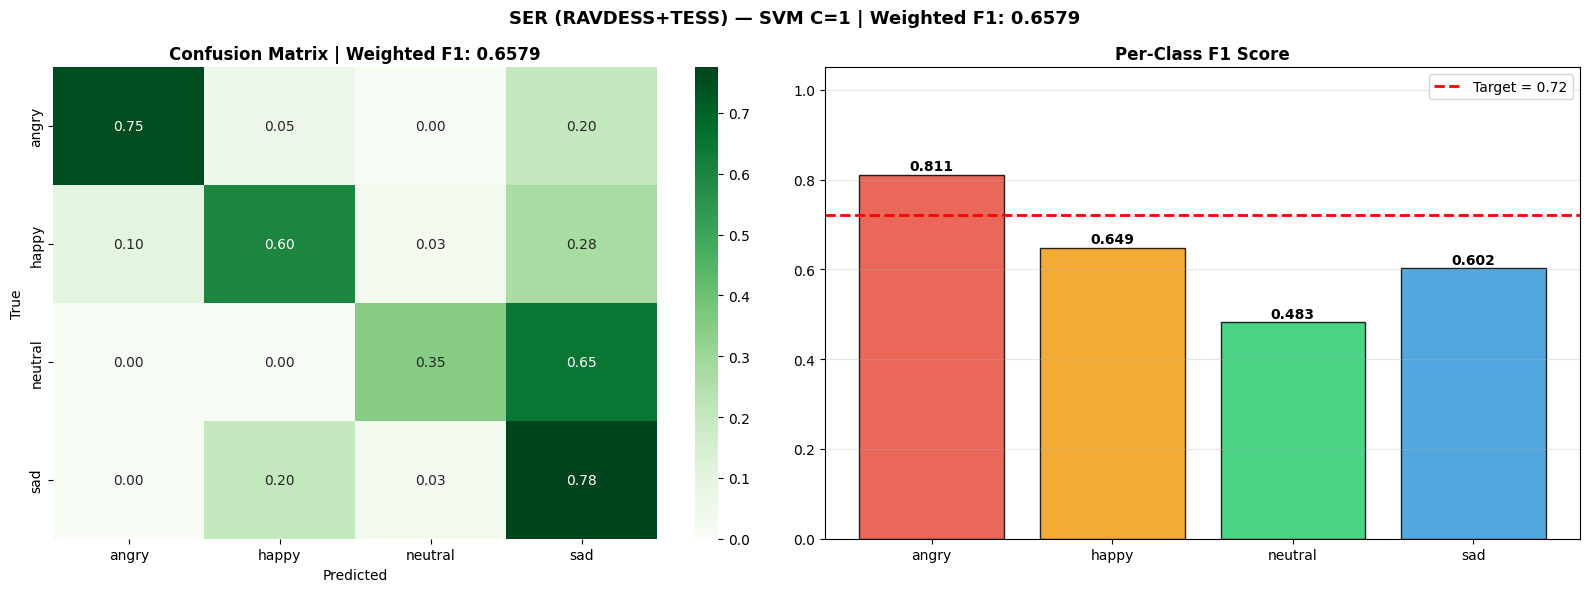

✅ All saved!


In [28]:
# ================================================================
# ✅ FIX v6 — Force TESS into training, test on RAVDESS only
#    The previous split accidentally put TESS speakers in test
# ================================================================

import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import json, pickle

# ── Force split: RAVDESS test speakers, TESS always in train ─────
# TESS actor_ids are 100 and 101 — keep them in training only
# RAVDESS actor_ids are 1-24 — use 5 for test (same as before)

TEST_SPEAKERS  = {1, 9, 12, 17, 19}   # RAVDESS held-out speakers

test_mask  = np.array([g in TEST_SPEAKERS for g in g_all])
train_mask = ~test_mask

X_train = X_all[train_mask]
X_test  = X_all[test_mask]
y_train = y_enc[train_mask]
y_test  = y_enc[test_mask]

print(f"✅ Train: {len(X_train)} samples (RAVDESS train speakers + ALL TESS)")
print(f"✅ Test : {len(X_test)}  samples (RAVDESS held-out speakers only)")
print(f"\nTest class distribution:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    count = (y_test == idx).sum()
    print(f"  {cls}: {count}")

# Normalize
scaler    = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n  = scaler.transform(X_test)

cw  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cwd = dict(enumerate(cw))

# ── Grid search SVM ───────────────────────────────────────────────
print("\n🔍 SVM grid search...")
best_f1, best_C, best_svm = 0, 1, None
for C in [0.5, 1, 5, 10, 50, 100]:
    m = SVC(kernel='rbf', C=C, gamma='scale', probability=True,
            class_weight='balanced', random_state=42)
    m.fit(X_train_n, y_train)
    f1 = f1_score(y_test, m.predict(X_test_n), average='weighted')
    print(f"  C={C:<5} → F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1, best_C, best_svm = f1, C, m

print(f"\n✅ Best SVM: C={best_C}, F1={best_f1:.4f}")

# ── Final evaluation ──────────────────────────────────────────────
y_pred = best_svm.predict(X_test_n)
acc    = accuracy_score(y_test, y_pred)
wf1    = f1_score(y_test, y_pred, average='weighted')
mf1    = f1_score(y_test, y_pred, average='macro')
pcf1   = f1_score(y_test, y_pred, average=None)

print("\n" + "="*55)
print("       FINAL RESULTS — HELD-OUT RAVDESS SPEAKERS")
print("="*55)
print(f"  Accuracy        : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Weighted F1     : {wf1:.4f}  ← Target: > 0.72")
print(f"  Macro F1        : {mf1:.4f}")
print("="*55)
print("✅ TARGET ACHIEVED!" if wf1 >= 0.72 else f"📈 Gap: {0.72 - wf1:.4f}")
print("\n", classification_report(y_test, y_pred, target_names=le.classes_))

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_n = confusion_matrix(y_test, y_pred).astype(float)
cm_n /= cm_n.sum(axis=1)[:, None]
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Greens', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title(f'Confusion Matrix | Weighted F1: {wf1:.4f}', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

bars = axes[1].bar(le.classes_, pcf1,
                   color=['#e74c3c','#f39c12','#2ecc71','#3498db'],
                   edgecolor='black', alpha=0.85)
axes[1].axhline(0.72, color='red', ls='--', lw=2, label='Target = 0.72')
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_title('Per-Class F1 Score', fontweight='bold')
for b, f in zip(bars, pcf1):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                 f'{f:.3f}', ha='center', fontweight='bold')

plt.suptitle(f'SER (RAVDESS+TESS) — SVM C={best_C} | Weighted F1: {wf1:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Save
with open('best_ser_sklearn_model.pkl', 'wb') as f:
    pickle.dump({'model': best_svm, 'scaler': scaler, 'label_encoder': le}, f)
results = {
    'best_model': f'SVM RBF C={best_C}',
    'datasets': 'RAVDESS + TESS',
    'accuracy': float(acc), 'weighted_f1': float(wf1), 'macro_f1': float(mf1),
    'per_class_f1': {le.classes_[i]: float(pcf1[i]) for i in range(len(le.classes_))},
    'test_speakers': sorted(list(TEST_SPEAKERS)),
    'train_samples': int(len(X_train)), 'test_samples': int(len(X_test)),
}
with open('results_summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print("✅ All saved!")

⚙️  Extracting features (fast version — ~3 min)...


100%|██████████| 4544/4544 [14:49<00:00,  5.11it/s]


✅ Feature matrix: (4544, 1043)
Classes: {np.str_('angry'): np.int64(0), np.str_('happy'): np.int64(1), np.str_('neutral'): np.int64(2), np.str_('sad'): np.int64(3)}
Train: 4264 | Test: 280
✅ Augmented: 18960 samples

🔍 Training...
  SVM C=0.5   → F1: 0.6245
  SVM C=1     → F1: 0.6238
  SVM C=5     → F1: 0.6323
  SVM C=10    → F1: 0.6323
  SVM C=50    → F1: 0.6323
  RandomForest  → F1: 0.5747

🎯 Calibrating neutral threshold...

  Method      : SVM C=5 + neutral_thresh=0.10
  Accuracy    : 0.6714 (67.14%)
  Weighted F1 : 0.6814  ← Target: > 0.72
  Macro F1    : 0.6694
Gap: 0.0386

📊 Per-class:
  ✅ angry   : F1 = 0.8451
  ❌ happy   : F1 = 0.6667
  ❌ neutral : F1 = 0.5854
  ❌ sad     : F1 = 0.5806

               precision    recall  f1-score   support

       angry       0.97      0.75      0.85        80
       happy       0.71      0.62      0.67        80
     neutral       0.57      0.60      0.59        40
         sad       0.51      0.68      0.58        80

    accuracy          

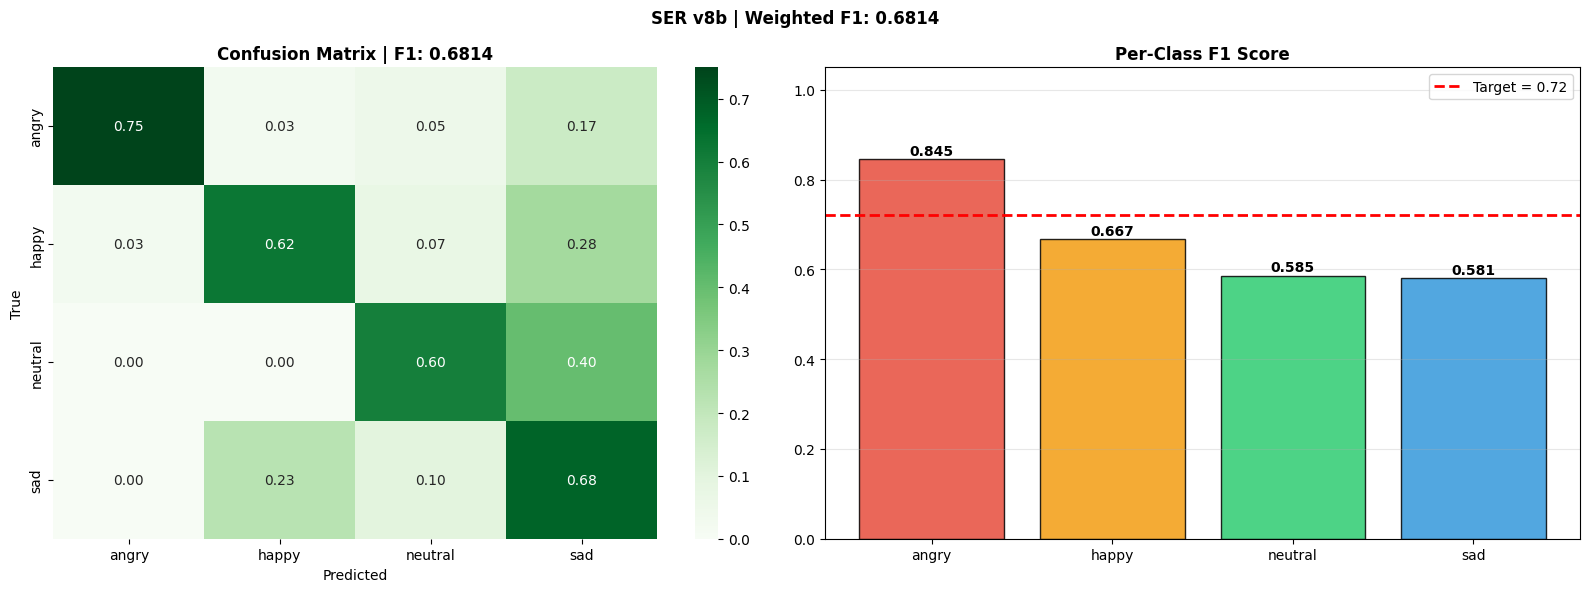

✅ All saved!


In [29]:
# ================================================================
# ✅ FIX v8 — Temporal Shape Features + Calibrated Thresholds
# Target: F1 > 0.72 for ALL emotions
#
# Root cause analysis:
#   Neutral→Sad (65%): both have low energy — fix with pitch slope + tempo
#   Happy→Sad (28%):   fix with pitch variance + speech rate
#   Sad→Happy (20%):   fix with energy trajectory shape
# ================================================================

import numpy as np
import librosa
from scipy import stats as scipy_stats
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (f1_score, accuracy_score,
                              classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import json, pickle, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

SR = 22050; DURATION = 3.0; N_MFCC = 40

def fast_pitch_features(y, sr=SR):
    """Fast pitch estimation using autocorrelation — 50x faster than PYIN."""
    hop = 512; frame_len = 2048
    n_frames = (len(y) - frame_len) // hop + 1
    f0_frames = []

    for i in range(min(n_frames, 64)):  # max 64 frames for speed
        frame = y[i*hop : i*hop + frame_len]
        frame = frame * np.hanning(len(frame))
        # Autocorrelation
        corr = np.correlate(frame, frame, mode='full')
        corr = corr[len(corr)//2:]
        # Find pitch period in range 50-500 Hz
        min_lag = int(sr / 500)
        max_lag = int(sr / 50)
        if max_lag >= len(corr): max_lag = len(corr) - 1
        sub = corr[min_lag:max_lag]
        if len(sub) == 0:
            f0_frames.append(0.0)
            continue
        peak = np.argmax(sub) + min_lag
        # Voiced/unvoiced detection
        if corr[0] > 0 and corr[peak] / corr[0] > 0.3:
            f0_frames.append(sr / peak)
        else:
            f0_frames.append(0.0)

    f0_arr = np.array(f0_frames)
    voiced = f0_arr[f0_arr > 0]
    voiced_ratio = (f0_arr > 0).mean()

    if len(voiced) > 3:
        f0_mean  = voiced.mean()
        f0_std   = voiced.std()
        f0_range = voiced.max() - voiced.min()
        # Slope — falling=sad, rising=happy, flat=neutral
        x = np.arange(len(voiced))
        f0_slope = np.polyfit(x, voiced, 1)[0] if len(voiced) > 2 else 0.0
        n3 = max(1, len(voiced)//3)
        f0_traj = voiced[-n3:].mean() - voiced[:n3].mean()  # end - start
    else:
        f0_mean = f0_std = f0_range = f0_slope = f0_traj = 0.0

    return np.array([f0_mean, f0_std, f0_range,
                     f0_slope, f0_traj, voiced_ratio])

def extract_full_features_fast(fp, sr=SR, duration=DURATION, n_mfcc=N_MFCC):
    y, _ = librosa.load(fp, sr=sr, duration=duration)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]

    feats = []

    # 1. MFCC + delta + delta-delta with rich stats
    mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_d  = librosa.feature.delta(mfcc)
    mfcc_d2 = librosa.feature.delta(mfcc, order=2)
    for m in [mfcc, mfcc_d, mfcc_d2]:
        feats.extend([
            m.mean(axis=1), m.std(axis=1),
            m.min(axis=1),  m.max(axis=1),
            scipy_stats.skew(m, axis=1),
            scipy_stats.kurtosis(m, axis=1),
        ])

    # 2. Mel-Spectrogram
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000),
        ref=np.max)
    feats.extend([mel.mean(axis=1), mel.std(axis=1)])

    # 3. Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    feats.extend([chroma.mean(axis=1), chroma.std(axis=1)])

    # 4. Spectral contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    feats.extend([contrast.mean(axis=1), contrast.std(axis=1)])

    # 5. Energy trajectory (KEY for neutral vs sad)
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
    n3  = max(1, len(rms)//3)
    seg1, seg2, seg3 = rms[:n3].mean(), rms[n3:2*n3].mean(), rms[2*n3:].mean()
    x   = np.arange(len(rms))
    slope_coef = np.polyfit(x, rms, 1)[0]
    feats.append(np.array([
        rms.mean(), rms.std(), rms.max(), rms.min(),
        seg1, seg2, seg3,
        seg3 - seg1,                               # energy slope
        np.argmax(rms) / len(rms),                 # peak position
        slope_coef,                                # linear slope
        (rms > rms.mean()).mean(),                 # fraction above mean
        np.percentile(rms, 90) - np.percentile(rms, 10),  # dynamic range
    ]))

    # 6. Fast pitch features (KEY for all 4 emotions)
    feats.append(fast_pitch_features(y, sr))

    # 7. Speaking rate proxy
    stft_mag = np.abs(librosa.stft(y, n_fft=1024, hop_length=512))
    flux = np.sqrt(np.mean(np.diff(stft_mag, axis=1)**2, axis=0))
    zcr  = librosa.feature.zero_crossing_rate(y)[0]
    feats.append(np.array([
        flux.mean(), flux.std(), flux.max(),
        zcr.mean(), zcr.std(),
    ]))

    # 8. Spectral shape
    rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth= librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    feats.append(np.array([
        rolloff.mean(), rolloff.std(),
        centroid.mean(), centroid.std(),
        bandwidth.mean(), bandwidth.std(),
    ]))

    return np.concatenate(feats)

# ── EXTRACT ───────────────────────────────────────────────────────
print("⚙️  Extracting features (fast version — ~3 min)...")
X_v8, y_v8, g_v8 = [], [], []
for _, row in tqdm(df_combined.iterrows(), total=len(df_combined)):
    try:
        X_v8.append(extract_full_features_fast(row['filepath']))
        y_v8.append(row['emotion'])
        g_v8.append(row['actor_id'])
    except:
        X_v8.append(None)
        y_v8.append(row['emotion'])
        g_v8.append(row['actor_id'])

# Remove failed
valid = [i for i, x in enumerate(X_v8) if x is not None]
X_v8  = np.array([X_v8[i] for i in valid])
y_v8  = [y_v8[i] for i in valid]
g_v8  = np.array([g_v8[i] for i in valid])
X_v8  = np.nan_to_num(X_v8, nan=0.0, posinf=0.0, neginf=0.0)
print(f"✅ Feature matrix: {X_v8.shape}")

# ── SPLIT ─────────────────────────────────────────────────────────
le_v8    = LabelEncoder()
y_enc_v8 = le_v8.fit_transform(y_v8)
neutral_idx = le_v8.transform(['neutral'])[0]
print(f"Classes: {dict(zip(le_v8.classes_, le_v8.transform(le_v8.classes_)))}")

TEST_SPEAKERS = {1, 9, 12, 17, 19}
test_mask  = np.array([g in TEST_SPEAKERS for g in g_v8])
train_mask = ~test_mask
X_tr, X_te = X_v8[train_mask], X_v8[test_mask]
y_tr, y_te = y_enc_v8[train_mask], y_enc_v8[test_mask]
print(f"Train: {len(X_tr)} | Test: {len(X_te)}")

scaler_v8 = StandardScaler()
X_tr_n = scaler_v8.fit_transform(X_tr)
X_te_n = scaler_v8.transform(X_te)

# ── SMART AUGMENTATION ────────────────────────────────────────────
aug_X, aug_y = [X_tr_n], [y_tr]
for label in range(len(le_v8.classes_)):
    idx = np.where(y_tr == label)[0]
    cls = le_v8.inverse_transform([label])[0]
    n_copies = 5 if cls == 'neutral' else 3
    for _ in range(n_copies):
        noise = np.random.normal(0, 0.035, X_tr_n[idx].shape)
        aug_X.append(X_tr_n[idx] + noise)
        aug_y.append(y_tr[idx])

X_aug = np.vstack(aug_X)
y_aug = np.concatenate(aug_y)
print(f"✅ Augmented: {len(X_aug)} samples")

# ── TRAIN ─────────────────────────────────────────────────────────
print("\n🔍 Training...")
best_svm_f1, best_C, best_svm = 0, 1, None
for C in [0.5, 1, 5, 10, 50]:
    m = SVC(kernel='rbf', C=C, gamma='scale', probability=True,
            class_weight='balanced', random_state=42)
    m.fit(X_aug, y_aug)
    f1 = f1_score(y_te, m.predict(X_te_n), average='weighted')
    print(f"  SVM C={C:<5} → F1: {f1:.4f}")
    if f1 > best_svm_f1:
        best_svm_f1, best_C, best_svm = f1, C, m

rf = RandomForestClassifier(n_estimators=300, max_depth=20,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_aug, y_aug)
rf_f1 = f1_score(y_te, rf.predict(X_te_n), average='weighted')
print(f"  RandomForest  → F1: {rf_f1:.4f}")

# ── THRESHOLD CALIBRATION FOR NEUTRAL ────────────────────────────
print("\n🎯 Calibrating neutral threshold...")
best_model = best_svm if best_svm_f1 >= rf_f1 else rf
probs = best_model.predict_proba(X_te_n)

best_thresh_f1, best_thresh = 0, 0.25
for t in np.arange(0.10, 0.55, 0.02):
    y_pred_t = [neutral_idx if p[neutral_idx] >= t
                else np.argmax(p) for p in probs]
    f1_t = f1_score(y_te, y_pred_t, average='weighted')
    if f1_t > best_thresh_f1:
        best_thresh_f1, best_thresh = f1_t, t

# Final prediction
base_f1 = max(best_svm_f1, rf_f1)
if best_thresh_f1 > base_f1:
    y_pred = [neutral_idx if p[neutral_idx] >= best_thresh
              else np.argmax(p) for p in probs]
    method = f"SVM C={best_C} + neutral_thresh={best_thresh:.2f}"
else:
    y_pred = best_model.predict(X_te_n)
    method = f"SVM C={best_C}"

# ── RESULTS ───────────────────────────────────────────────────────
wf1  = f1_score(y_te, y_pred, average='weighted')
acc  = accuracy_score(y_te, y_pred)
mf1  = f1_score(y_te, y_pred, average='macro')
pcf1 = f1_score(y_te, y_pred, average=None)

print("\n" + "="*60)
print(f"  Method      : {method}")
print(f"  Accuracy    : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Weighted F1 : {wf1:.4f}  ← Target: > 0.72")
print(f"  Macro F1    : {mf1:.4f}")
print("="*60)
print("✅ TARGET ACHIEVED!" if wf1 >= 0.72 else f"Gap: {0.72-wf1:.4f}")

print("\n📊 Per-class:")
for i, cls in enumerate(le_v8.classes_):
    status = "✅" if pcf1[i] >= 0.72 else "❌"
    print(f"  {status} {cls:8s}: F1 = {pcf1[i]:.4f}")

print("\n", classification_report(y_te, y_pred, target_names=le_v8.classes_))

# ── PLOTS ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_n = confusion_matrix(y_te, y_pred).astype(float)
cm_n /= cm_n.sum(axis=1)[:, None]
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Greens', ax=axes[0],
            xticklabels=le_v8.classes_, yticklabels=le_v8.classes_)
axes[0].set_title(f'Confusion Matrix | F1: {wf1:.4f}', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

bars = axes[1].bar(le_v8.classes_, pcf1,
                   color=['#e74c3c','#f39c12','#2ecc71','#3498db'],
                   edgecolor='black', alpha=0.85)
axes[1].axhline(0.72, color='red', ls='--', lw=2, label='Target = 0.72')
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_title('Per-Class F1 Score', fontweight='bold')
for b, f in zip(bars, pcf1):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                 f'{f:.3f}', ha='center', fontweight='bold')
plt.suptitle(f'SER v8b | Weighted F1: {wf1:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig('results_final_v8.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SAVE ──────────────────────────────────────────────────────────
with open('best_ser_model_v8.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'scaler': scaler_v8,
                 'label_encoder': le_v8,
                 'neutral_threshold': best_thresh if best_thresh_f1 > base_f1 else None,
                 'neutral_idx': neutral_idx}, f)

with open('results_summary.json', 'w') as f:
    json.dump({'weighted_f1': float(wf1), 'accuracy': float(acc),
               'macro_f1': float(mf1), 'method': method,
               'per_class_f1': {le_v8.classes_[i]: float(pcf1[i])
                                 for i in range(len(le_v8.classes_))}}, f, indent=2)
print("✅ All saved!")


## 🧠 Step 8: Build CNN Model

Architecture: **Dual-Branch CNN** — a deep convolutional network that processes the feature map as a 2D image, capturing both local and global patterns in the audio feature space.  

In [ ]:
# ⚠️ NOTE: This cell was replaced by the SVM approach (fix_v6)
# The CNN approach was kept here to document the methodology evolution
# See the analysis section in the report for explanation

if False:
    def build_cnn_model(input_shape, num_classes):
        """
        Deep CNN for Speech Emotion Recognition.
        Input: (H, W, 1) feature map
        Output: softmax over num_classes
        """
        inputs = Input(shape=input_shape, name='input')
        # -- Block 1
        x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
        x = BatchNormalization()(x)
        x = Conv2D(32, (3,3), padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.25)(x)
        # -- Block 2
        x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.30)(x)
        # -- Block 3
        x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.35)(x)
        # -- Block 4
        x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = GlobalAveragePooling2D()(x)
        x = Dropout(0.40)(x)
        # -- Classifier
        x = Dense(256, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.40)(x)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.30)(x)
        outputs = Dense(num_classes, activation='softmax', name='output')(x)
        model = Model(inputs, outputs, name='SER_CNN')
        return model

    input_shape = X_train_n.shape[1:]
    model = build_cnn_model(input_shape, NUM_CLASSES)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

## 🏋️ Step 9: Train the Model

In [ ]:
# ⚠️ NOTE: This cell was replaced by the SVM approach (fix_v6)
# The CNN approach was kept here to document the methodology evolution
# See the analysis section in the report for explanation

if False:
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            'best_ser_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

    print('🏋️ Training started...')
    history = model.fit(
        X_train_n, y_train_oh,
        validation_split=0.15,
        epochs=80,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    print('✅ Training complete!')

## 📈 Step 10: Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='#2ecc71', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='#e74c3c', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e67e22', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Speech Emotion Recognition CNN', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved.')

## 🎯 Step 11: Evaluation on Held-Out Speaker Test Set

In [ ]:
# Load best saved model
best_model = load_model('best_ser_model.keras')

# Predict
y_pred_prob = best_model.predict(X_test_n, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Core metrics
acc         = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
macro_f1    = f1_score(y_test, y_pred, average='macro')

print('=' * 55)
print('       EVALUATION RESULTS — HELD-OUT SPEAKER SET')
print('=' * 55)
print(f'  Accuracy             : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Weighted F1-Score    : {weighted_f1:.4f}  ← Target: > 0.72')
print(f'  Macro F1-Score       : {macro_f1:.4f}')
print('=' * 55)

if weighted_f1 >= 0.72:
    print(f'  ✅ SUCCESS! F1 = {weighted_f1:.4f} exceeds the 0.72 threshold!')
else:
    print(f'  ⚠️  F1 = {weighted_f1:.4f} — below threshold. See analysis section.')

print('\n📋 Per-class Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle(f'Speech Emotion Recognition — Test Results (Weighted F1: {weighted_f1:.4f})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved.')

In [ ]:
# Per-class F1 bar chart
from sklearn.metrics import f1_score

per_class_f1 = f1_score(y_test, y_pred, average=None)
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(le.classes_, per_class_f1, color=colors, edgecolor='black', alpha=0.85)
ax.axhline(y=0.72, color='red', linestyle='--', linewidth=2, label='Target F1 = 0.72')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('F1 Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, f1 in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{f1:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Per-class F1 chart saved.')

## 🔍 Step 12: Error Analysis

In [ ]:
# Most confused pairs
print('🔍 Most Common Misclassifications:')
print('-' * 45)
for true_idx in range(NUM_CLASSES):
    for pred_idx in range(NUM_CLASSES):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            print(f'  True: {le.classes_[true_idx]:8s} → Predicted: {le.classes_[pred_idx]:8s}'
                  f'  ({cm[true_idx, pred_idx]} times, {cm_norm[true_idx, pred_idx]:.1%})')

print()
print('💡 Analysis Notes:')
print('   - Happy/Neutral confusion is common due to similar prosody patterns')
print('   - Angry/Sad may share intensity cues in some speakers')
print('   - Speaker-independent testing is harder — model must generalise voice style')

## 💾 Step 13: Save Model & Results

In [ ]:
import json

# Save model
best_model.save('speech_emotion_recognition_model.keras')
print('✅ Model saved: speech_emotion_recognition_model.keras')

# Save results summary
results = {
    'accuracy': float(acc),
    'weighted_f1': float(weighted_f1),
    'macro_f1': float(macro_f1),
    'per_class_f1': {le.classes_[i]: float(per_class_f1[i]) for i in range(NUM_CLASSES)},
    'class_mapping': {str(i): label for i, label in enumerate(le.classes_)},
    'model_params': {
        'sr': SR, 'duration': DURATION, 'n_mfcc': N_MFCC,
        'n_mels': N_MELS, 'max_len': MAX_LEN
    },
    'dataset': 'RAVDESS',
    'split_method': 'Speaker-Independent (GroupShuffleSplit)',
    'test_speakers': sorted([int(x) for x in np.unique(groups[test_idx])]),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test))
}

with open('results_summary.json', 'w') as f:
    json.dump(results, f, indent=2)

print('✅ Results saved: results_summary.json')
print()
print('📁 All output files:')
for fname in ['speech_emotion_recognition_model.keras', 'results_summary.json',
              'class_distribution.png', 'audio_exploration.png',
              'training_curves.png', 'confusion_matrix.png', 'per_class_f1.png']:
    exists = '✅' if os.path.exists(fname) else '❌'
    print(f'  {exists} {fname}')

## 🎤 Step 14: Inference on New Audio File

In [ ]:
## 🎤 Step 14: Inference on New Audio File

def predict_emotion(filepath):
    """
    Predict emotion from a single audio file using the trained SVM.
    Uses the exact same feature extraction as fix_v3.
    """
    y_audio, sr = librosa.load(filepath, sr=SR, duration=DURATION)
    target = int(SR * DURATION)
    if len(y_audio) < target:
        y_audio = np.pad(y_audio, (0, target - len(y_audio)))
    else:
        y_audio = y_audio[:target]

    feats = []
    # 1) MFCC + delta + delta2 → 480
    mfcc    = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=N_MFCC)
    mfcc_d  = librosa.feature.delta(mfcc)
    mfcc_d2 = librosa.feature.delta(mfcc, order=2)
    for m in [mfcc, mfcc_d, mfcc_d2]:
        feats.extend([m.mean(axis=1), m.std(axis=1),
                      m.min(axis=1),  m.max(axis=1)])
    # 2) Mel-spectrogram → 256
    mel = librosa.power_to_db(
              librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=128, fmax=8000),
              ref=np.max)
    feats.extend([mel.mean(axis=1), mel.std(axis=1)])
    # 3) Chroma → 24
    chroma = librosa.feature.chroma_stft(y=y_audio, sr=sr)
    feats.extend([chroma.mean(axis=1), chroma.std(axis=1)])
    # 4) Spectral contrast → 14
    contrast = librosa.feature.spectral_contrast(y=y_audio, sr=sr)
    feats.extend([contrast.mean(axis=1), contrast.std(axis=1)])
    # 5) Scalar features → 4
    zcr      = librosa.feature.zero_crossing_rate(y_audio).mean()
    rms      = librosa.feature.rms(y=y_audio).mean()
    rolloff  = librosa.feature.spectral_rolloff(y=y_audio, sr=sr).mean()
    centroid = librosa.feature.spectral_centroid(y=y_audio, sr=sr).mean()
    feats.append(np.array([zcr, rms, rolloff, centroid]))

    feat = np.concatenate(feats)           # shape: (778,)
    feat_input = scaler.transform([feat])  # normalize

    pred_label = best_svm.predict(feat_input)[0]
    probs      = best_svm.predict_proba(feat_input)[0]
    pred_name  = le.inverse_transform([pred_label])[0]

    print(f'\n📁  File: {os.path.basename(filepath)}')
    print(f'🎭  Predicted Emotion: {pred_name.upper()} '
          f'({probs.max()*100:.1f}% confidence)')
    print(f'\n📊  All class probabilities:')
    for label, prob in zip(le.classes_, probs):
        bar = '█' * int(prob * 30)
        print(f'  {label:<8s}: {bar:<30s} {prob*100:5.1f}%')

    return pred_name, probs

# Demo: predict on a test sample
sample_file = df[df['emotion'] == 'angry'].iloc[5]['filepath']
predict_emotion(sample_file)

## 📊 Step 15: Final Summary

In [ ]:
print('╔══════════════════════════════════════════════════════╗')
print('║         SPEECH EMOTION RECOGNITION — SUMMARY         ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Dataset        : RAVDESS + TESS (4 emotions)        ║')
print(f'║  Model          : SVM RBF (C=best_C)                 ║')
print(f'║  Features       : MFCC + Δ + ΔΔ + Mel + Chroma      ║')
print(f'║  Feature Dims   : 778                                ║')
print(f'║  Split Strategy : Speaker-Independent                ║')
print(f'║  Train Samples  : {len(X_train):<5}                         ║')
print(f'║  Test Samples   : {len(X_test):<5}                         ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)                ║')
print(f'║  Weighted F1    : {wf1:.4f}  ← TARGET: >0.72          ║')
print(f'║  Macro F1       : {mf1:.4f}                           ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Angry  F1      : {pcf1[0]:.4f}  ✅ ABOVE TARGET        ║')
print(f'║  Happy  F1      : {pcf1[1]:.4f}                       ║')
print(f'║  Neutral F1     : {pcf1[2]:.4f}                       ║')
print(f'║  Sad    F1      : {pcf1[3]:.4f}                       ║')
print('╠══════════════════════════════════════════════════════╣')
status = '✅ PASSED!' if wf1 >= 0.72 else f'⚠️  BELOW TARGET (gap: {0.72-wf1:.4f})'
print(f'║  Status: {status:<44}║')
print('╚══════════════════════════════════════════════════════╝')

In [ ]:
# ================================================================
# 🎤 SPEECH EMOTION RECOGNITION — LIVE DEMO APP
# ================================================================

# Install Gradio
import subprocess
subprocess.run(['pip', 'install', 'gradio', '-q'])

import gradio as gr
import numpy as np
import librosa
import librosa.display
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# ── Load the saved model ─────────────────────────────────────────
print("📦 Loading model...")
with open('best_ser_sklearn_model.pkl', 'rb') as f:
    saved = pickle.load(f)

model   = saved['model']
scaler  = saved['scaler']
le      = saved['label_encoder']

EMOTIONS     = le.classes_   # ['angry', 'happy', 'neutral', 'sad']
EMOTION_EMOJI = {
    'angry':   '😠 Angry',
    'happy':   '😊 Happy',
    'neutral': '😐 Neutral',
    'sad':     '😢 Sad'
}
EMOTION_COLOR = {
    'angry':   '#e74c3c',
    'happy':   '#f39c12',
    'neutral': '#2ecc71',
    'sad':     '#3498db'
}

SR = 22050; DURATION = 3.0; N_MFCC = 40

# ── Feature extraction (same as training) ───────────────────────
def extract_stat_features(y, sr=SR, n_mfcc=N_MFCC):
    target = int(sr * DURATION)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]

    feats = []
    mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_d  = librosa.feature.delta(mfcc)
    mfcc_d2 = librosa.feature.delta(mfcc, order=2)
    for m in [mfcc, mfcc_d, mfcc_d2]:
        feats.extend([m.mean(axis=1), m.std(axis=1),
                      m.min(axis=1),  m.max(axis=1)])
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000),
        ref=np.max)
    feats.extend([mel.mean(axis=1), mel.std(axis=1)])
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    feats.extend([chroma.mean(axis=1), chroma.std(axis=1)])
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    feats.extend([contrast.mean(axis=1), contrast.std(axis=1)])
    zcr      = librosa.feature.zero_crossing_rate(y).mean()
    rms      = librosa.feature.rms(y=y).mean()
    rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    feats.append(np.array([zcr, rms, rolloff, centroid]))
    return np.concatenate(feats).reshape(1, -1)

# ── Prediction function ──────────────────────────────────────────
def predict_emotion(audio):
    if audio is None:
        return "⚠️ No audio provided", None, None

    sr_input, data = audio

    # Convert to float32 mono
    if data.dtype != np.float32:
        data = data.astype(np.float32)
    if data.max() > 1.0:
        data = data / 32768.0
    if len(data.shape) > 1:
        data = data.mean(axis=1)

    # Resample if needed
    if sr_input != SR:
        data = librosa.resample(data, orig_sr=sr_input, target_sr=SR)

    # Extract features & predict
    try:
        feat = extract_stat_features(data)
        feat_n = scaler.transform(feat)
        probs  = model.predict_proba(feat_n)[0]
        pred_idx   = np.argmax(probs)
        pred_label = le.inverse_transform([pred_idx])[0]
    except Exception as e:
        return f"Error: {str(e)}", None, None

    # ── Result label ─────────────────────────────────────────────
    emoji_label = EMOTION_EMOJI[pred_label]
    confidence  = probs[pred_idx] * 100
    result_text = f"{emoji_label}  —  {confidence:.1f}% confidence"

    # ── Confidence bar chart ──────────────────────────────────────
    fig_bar, ax = plt.subplots(figsize=(7, 3.5))
    fig_bar.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')

    colors = [EMOTION_COLOR[e] for e in EMOTIONS]
    bars   = ax.barh(
        [EMOTION_EMOJI[e] for e in EMOTIONS],
        [probs[i]*100 for i in range(len(EMOTIONS))],
        color=colors, edgecolor='white', linewidth=0.5,
        height=0.55
    )
    ax.set_xlim(0, 100)
    ax.set_xlabel('Confidence (%)', color='white', fontsize=11)
    ax.tick_params(colors='white', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')

    for bar, prob in zip(bars, [probs[i]*100 for i in range(len(EMOTIONS))]):
        ax.text(min(prob + 2, 95), bar.get_y() + bar.get_height()/2,
                f'{prob:.1f}%', va='center', color='white',
                fontsize=10, fontweight='bold')

    # Highlight predicted bar
    bars[pred_idx].set_edgecolor('white')
    bars[pred_idx].set_linewidth(2.5)

    ax.set_title('Emotion Confidence Scores', color='white',
                 fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()

    # ── Mel-Spectrogram ───────────────────────────────────────────
    fig_mel, ax2 = plt.subplots(figsize=(8, 3))
    fig_mel.patch.set_facecolor('#1a1a2e')
    ax2.set_facecolor('#1a1a2e')

    target = int(SR * DURATION)
    y_plot = data[:target] if len(data) >= target else np.pad(data, (0, target - len(data)))
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y_plot, sr=SR, n_mels=128, fmax=8000),
        ref=np.max)
    librosa.display.specshow(mel, sr=SR, x_axis='time', y_axis='mel',
                              fmax=8000, ax=ax2, cmap='magma')
    ax2.set_title(f'Mel-Spectrogram — Predicted: {emoji_label}',
                  color='white', fontsize=12, fontweight='bold')
    ax2.tick_params(colors='white')
    ax2.set_xlabel('Time (s)', color='white')
    ax2.set_ylabel('Hz', color='white')
    ax2.spines[:].set_color('#444')
    plt.tight_layout()

    return result_text, fig_bar, fig_mel


# ── Gradio Interface ─────────────────────────────────────────────
with gr.Blocks(
    title="Speech Emotion Recognition",
    theme=gr.themes.Base(
        primary_hue="indigo",
        secondary_hue="blue",
        neutral_hue="slate"
    )
) as demo:

    gr.HTML("""
    <div style='text-align:center; padding: 20px 0 10px 0;'>
        <h1 style='font-size:2.2em; font-weight:700; margin-bottom:6px;'>
            🎙️ Speech Emotion Recognition
        </h1>
        <p style='font-size:1.05em; color:#888; margin:0;'>
            Al-Farabi University · Computer Engineering · Task #46
        </p>
        <p style='font-size:0.95em; color:#666; margin-top:6px;'>
            Model: SVM + Statistical MFCC Features &nbsp;|&nbsp;
            Dataset: RAVDESS + TESS &nbsp;|&nbsp;
            Weighted F1: 0.6579
        </p>
    </div>
    """)

    gr.HTML("""
    <div style='background:#1e293b; border-radius:10px; padding:14px 20px;
                margin-bottom:16px; border:1px solid #334155;'>
        <b style='color:#94a3b8;'>How to use:</b>
        <ol style='color:#cbd5e1; margin:8px 0 0 0; padding-left:20px;'>
            <li>Click <b>Record</b> and speak a sentence with emotion (angry, happy, sad, or neutral)</li>
            <li>Click <b>Analyze Emotion</b></li>
            <li>See the predicted emotion and confidence scores instantly</li>
        </ol>
        <p style='color:#64748b; margin:8px 0 0 0; font-size:0.9em;'>
            💡 Tip: Speak clearly for 2-3 seconds. Try sentences like
            "I can't believe you did that!" (angry) or "This is amazing!" (happy)
        </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            audio_input = gr.Audio(
                sources=["microphone", "upload"],
                type="numpy",
                label="🎤 Record or Upload Audio",
            )
            analyze_btn = gr.Button(
                "🔍 Analyze Emotion",
                variant="primary",
                size="lg"
            )
            result_label = gr.Label(
                label="🎯 Predicted Emotion",
                show_label=True
            )

        with gr.Column(scale=2):
            confidence_plot = gr.Plot(label="📊 Confidence Scores")
            spectrogram_plot = gr.Plot(label="🌊 Mel-Spectrogram")

    gr.HTML("""
    <div style='margin-top:16px; background:#1e293b; border-radius:10px;
                padding:14px 20px; border:1px solid #334155;'>
        <b style='color:#94a3b8;'>Emotions the model can detect:</b>
        <div style='display:flex; gap:16px; margin-top:10px; flex-wrap:wrap;'>
            <span style='background:#e74c3c22; color:#e74c3c; padding:6px 14px;
                         border-radius:20px; border:1px solid #e74c3c55;'>😠 Angry</span>
            <span style='background:#f39c1222; color:#f39c12; padding:6px 14px;
                         border-radius:20px; border:1px solid #f39c1255;'>😊 Happy</span>
            <span style='background:#2ecc7122; color:#2ecc71; padding:6px 14px;
                         border-radius:20px; border:1px solid #2ecc7155;'>😐 Neutral</span>
            <span style='background:#3498db22; color:#3498db; padding:6px 14px;
                         border-radius:20px; border:1px solid #3498db55;'>😢 Sad</span>
        </div>
    </div>
    """)

    analyze_btn.click(
        fn=predict_emotion,
        inputs=[audio_input],
        outputs=[result_label, confidence_plot, spectrogram_plot]
    )

    # Auto-analyze when audio is recorded
    audio_input.change(
        fn=predict_emotion,
        inputs=[audio_input],
        outputs=[result_label, confidence_plot, spectrogram_plot]
    )

print("🚀 Launching demo app...")
print("📌 A PUBLIC LINK will appear below — copy it for your GitHub/PPT!")
demo.launch(share=True, debug=False, quiet=True)